In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [2]:
# Load dataset
df = pd.read_csv("/content/sample_data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

print(df.head())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [3]:
# Shape of the dataset
print("Dataset shape:", df.shape)

Dataset shape: (7043, 21)


In [4]:
# Column names
print("\nColumns:\n", df.columns.tolist())


Columns:
 ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [5]:
# Basic information
print("\nDataset info:")
print(df.info())


Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-

In [6]:
# Summary statistics for numerical columns
print("\nSummary statistics:")
print(df.describe(include='all'))


Summary statistics:
        customerID gender  SeniorCitizen Partner Dependents       tenure  \
count         7043   7043    7043.000000    7043       7043  7043.000000   
unique        7043      2            NaN       2          2          NaN   
top     3186-AJIEK   Male            NaN      No         No          NaN   
freq             1   3555            NaN    3641       4933          NaN   
mean           NaN    NaN       0.162147     NaN        NaN    32.371149   
std            NaN    NaN       0.368612     NaN        NaN    24.559481   
min            NaN    NaN       0.000000     NaN        NaN     0.000000   
25%            NaN    NaN       0.000000     NaN        NaN     9.000000   
50%            NaN    NaN       0.000000     NaN        NaN    29.000000   
75%            NaN    NaN       0.000000     NaN        NaN    55.000000   
max            NaN    NaN       1.000000     NaN        NaN    72.000000   

       PhoneService MultipleLines InternetService OnlineSecurity  

In [7]:
# Missing values count
print("\nMissing values in each column:")
print(df.isnull().sum())


Missing values in each column:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [8]:
df.drop("customerID", axis=1, inplace=True)

In [9]:
print("\nColumns:\n", df.columns.tolist())


Columns:
 ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [10]:
# Convert blank spaces to NaN, then convert to numeric
df["TotalCharges"] = df["TotalCharges"].replace(" ", np.nan)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"])

In [11]:
print(df.isnull().sum())

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


In [12]:
df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)

In [13]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 22


In [14]:
df.drop_duplicates(inplace=True)

In [15]:
# Encode target variable
label_encoder = LabelEncoder()
df["Churn"] = label_encoder.fit_transform(df["Churn"])

# Check mapping
print(dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))

{'No': np.int64(0), 'Yes': np.int64(1)}


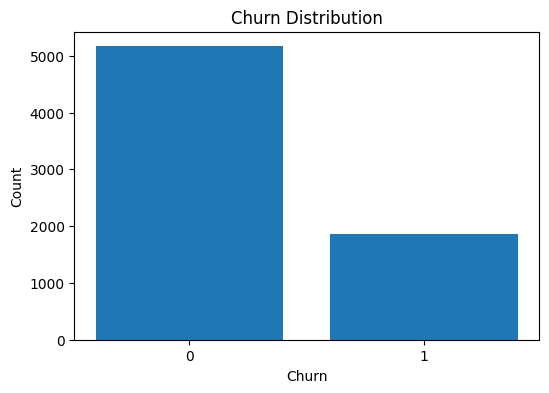

Churn
0    0.735508
1    0.264492
Name: proportion, dtype: float64


In [16]:
churn_counts = df["Churn"].value_counts()

plt.figure(figsize=(6,4))
plt.bar(churn_counts.index.astype(str), churn_counts.values)
plt.xlabel("Churn")
plt.ylabel("Count")
plt.title("Churn Distribution")
plt.show()

print(df["Churn"].value_counts(normalize=True))

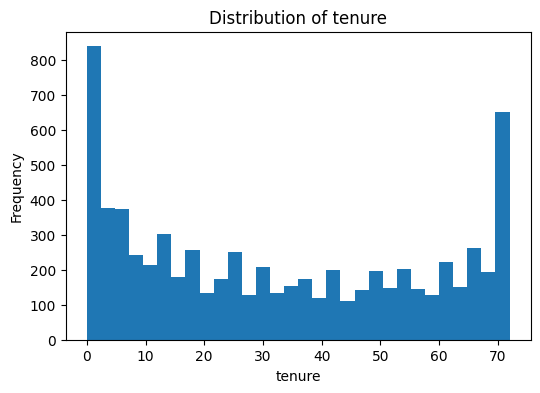

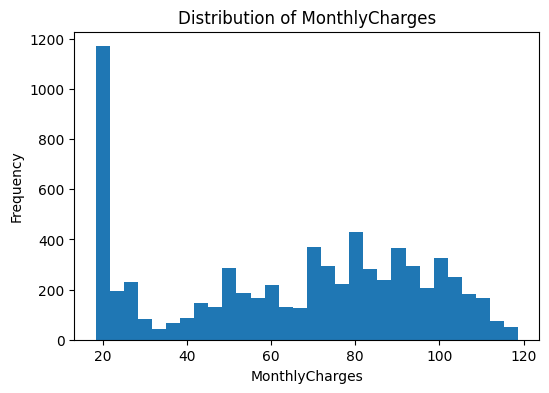

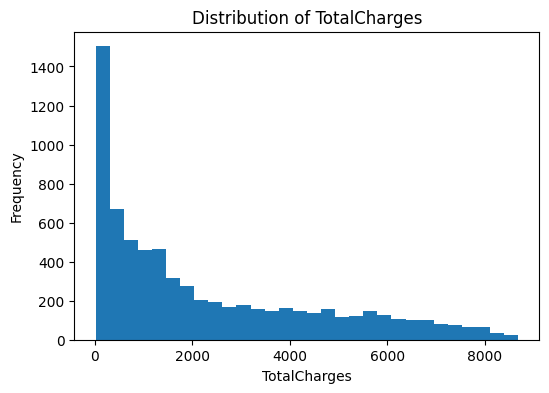

In [17]:
numerical_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

for col in numerical_cols:
    plt.figure(figsize=(6,4))
    plt.hist(df[col], bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

<Figure size 600x400 with 0 Axes>

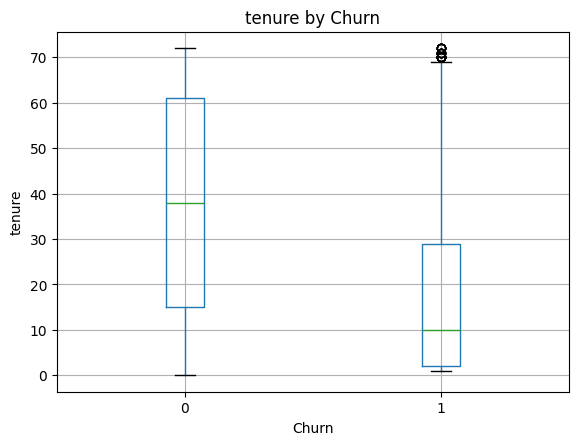

<Figure size 600x400 with 0 Axes>

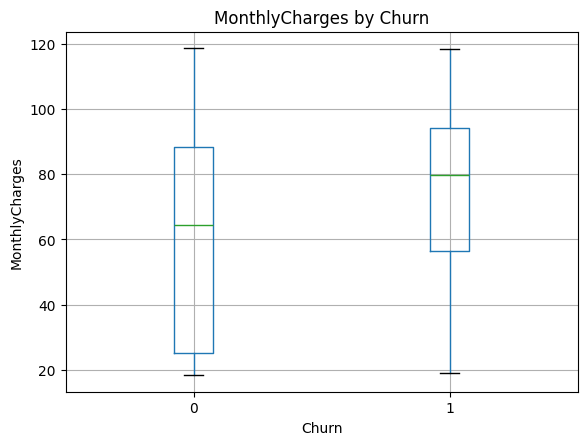

<Figure size 600x400 with 0 Axes>

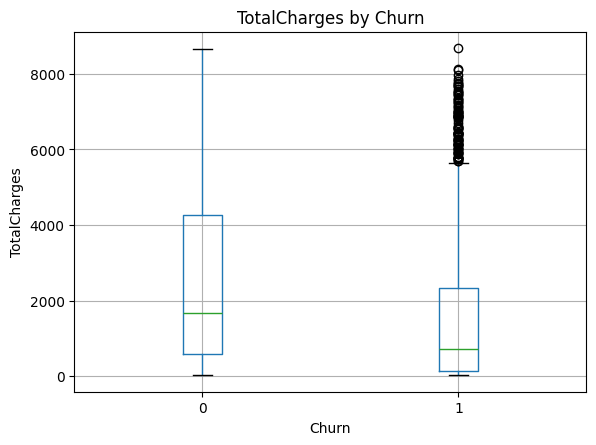

In [18]:
for col in numerical_cols:
    plt.figure(figsize=(6,4))
    df.boxplot(column=col, by="Churn")
    plt.title(f"{col} by Churn")
    plt.suptitle("")
    plt.xlabel("Churn")
    plt.ylabel(col)
    plt.show()

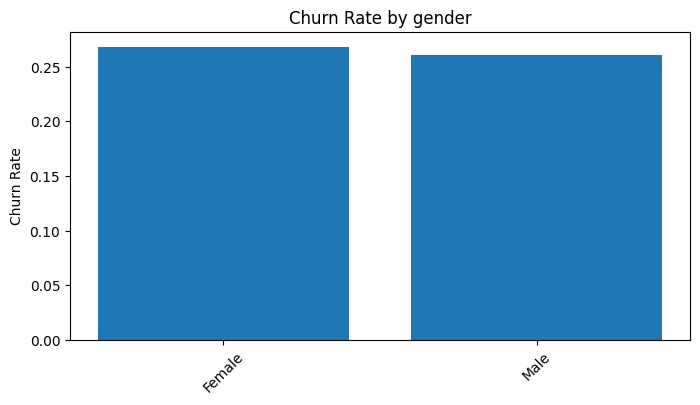

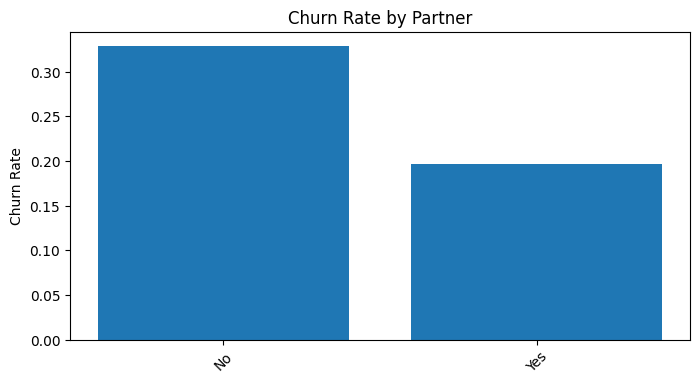

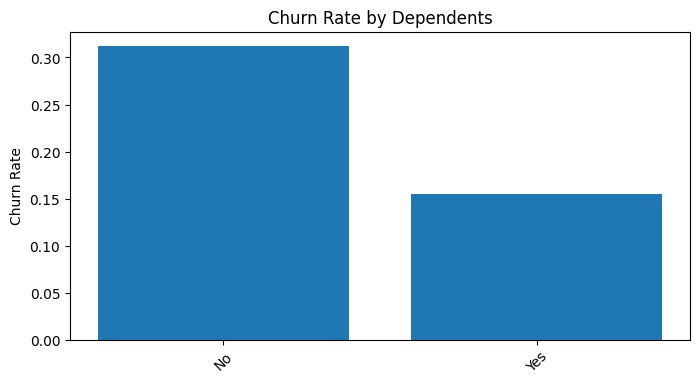

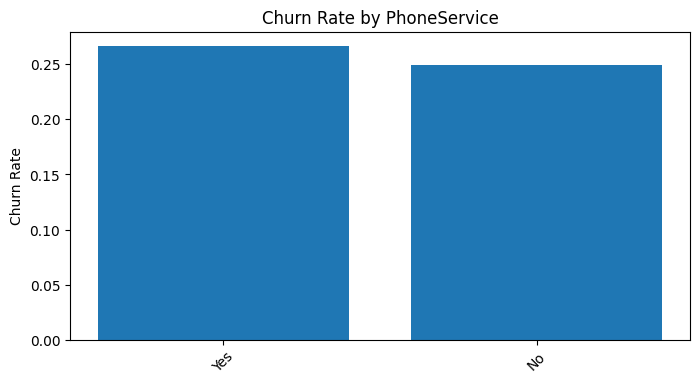

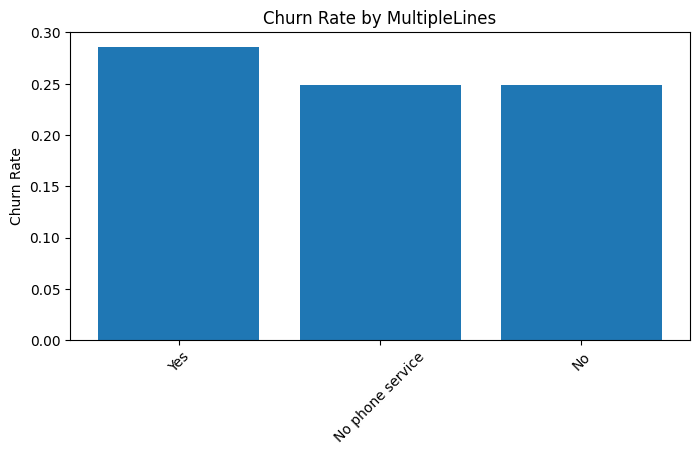

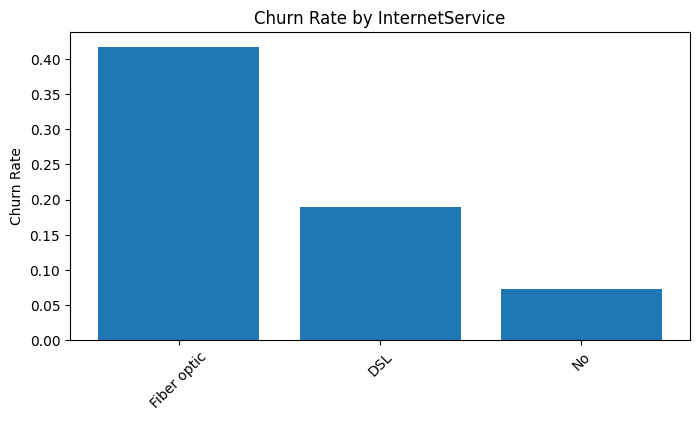

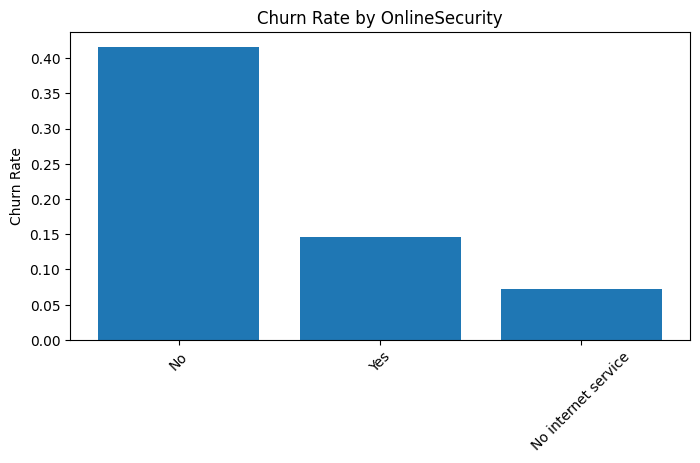

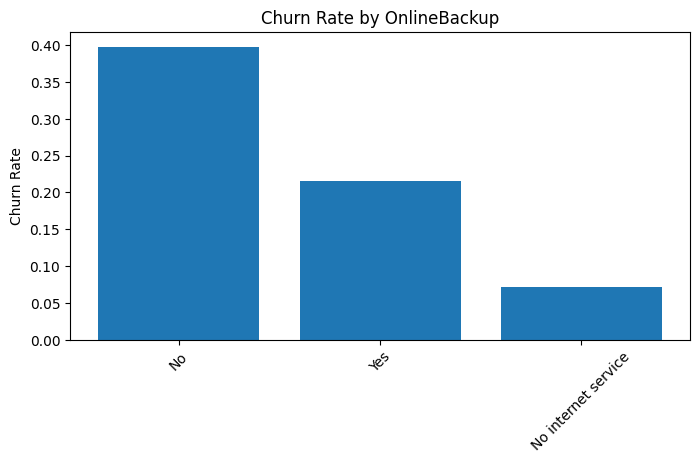

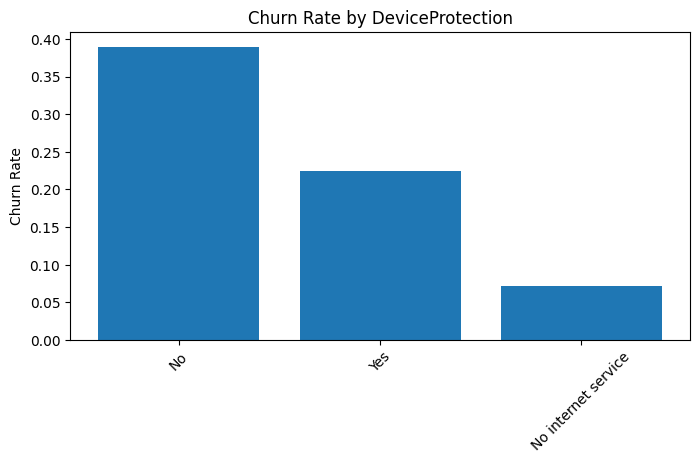

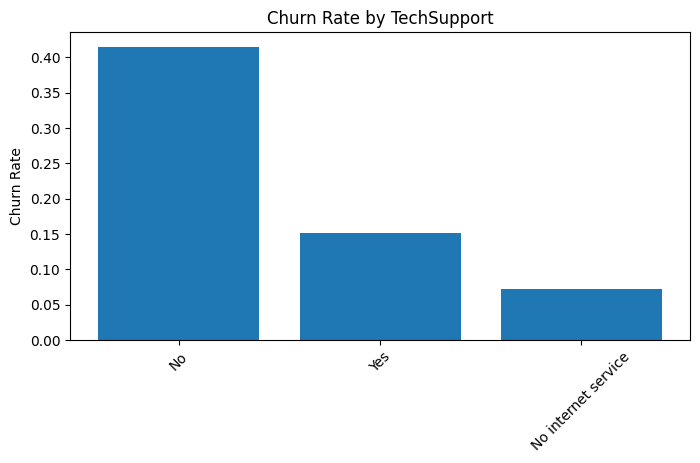

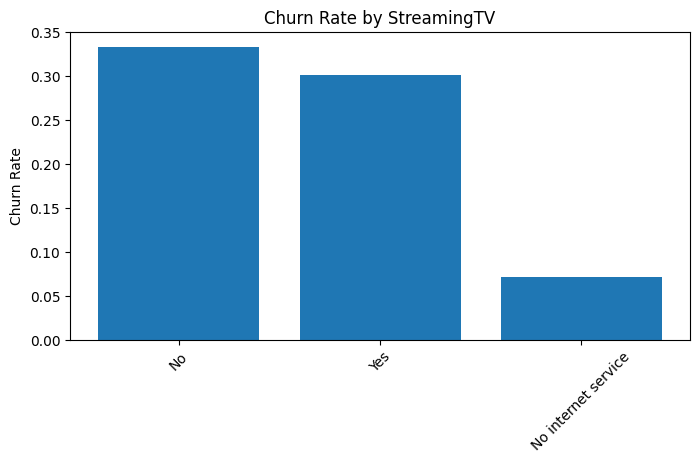

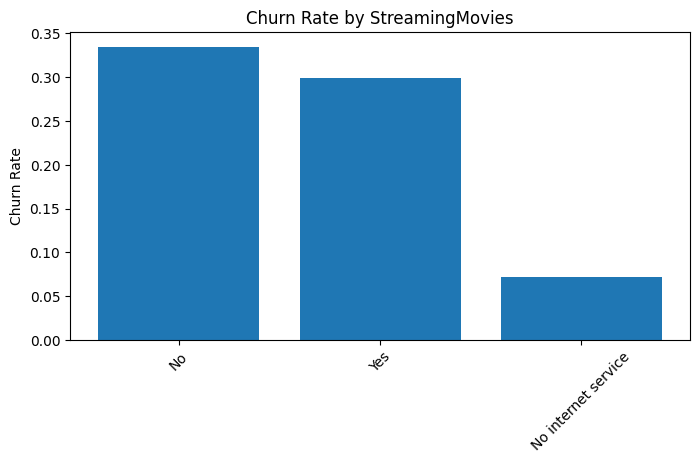

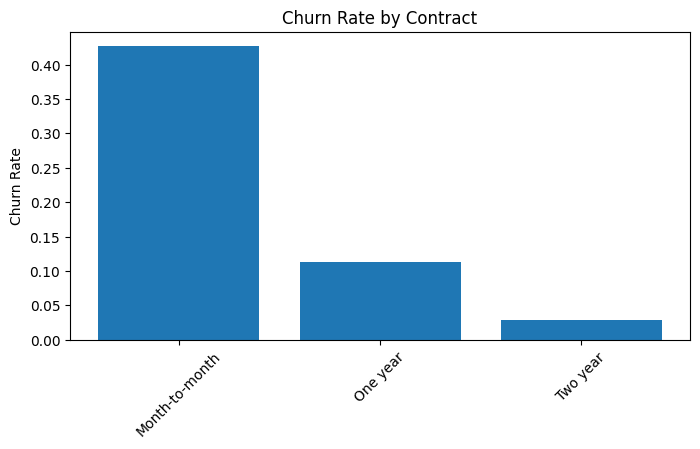

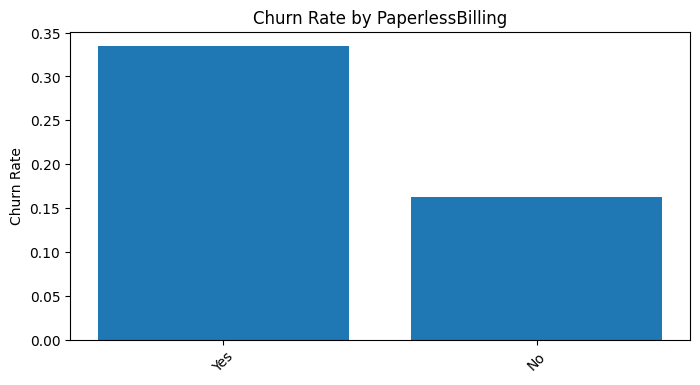

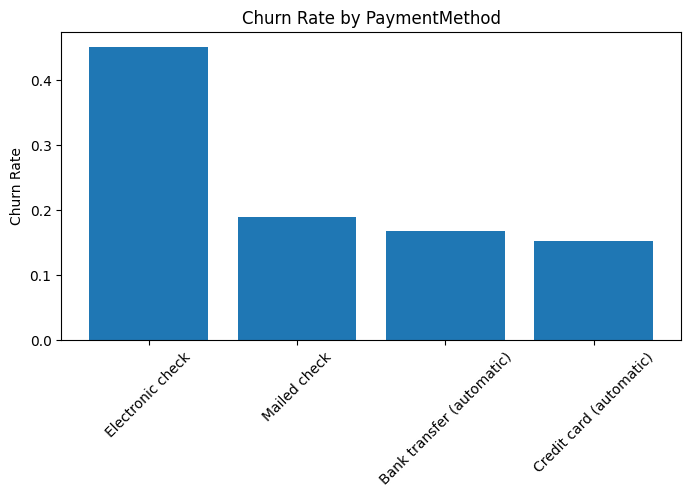

In [19]:
categorical_cols = df.select_dtypes(include="object").columns.tolist()

for col in categorical_cols:
    churn_rate = df.groupby(col)["Churn"].mean().sort_values(ascending=False)

    plt.figure(figsize=(8,4))
    plt.bar(churn_rate.index.astype(str), churn_rate.values)
    plt.xticks(rotation=45)
    plt.ylabel("Churn Rate")
    plt.title(f"Churn Rate by {col}")
    plt.show()

In [20]:
def tenure_group(tenure):
    if tenure <= 12:
        return "0-12 Months"
    elif tenure <= 24:
        return "13-24 Months"
    elif tenure <= 48:
        return "25-48 Months"
    else:
        return "49+ Months"

df["TenureGroup"] = df["tenure"].apply(tenure_group)

In [21]:
service_cols = [
    "PhoneService", "MultipleLines", "InternetService", "OnlineSecurity",
    "OnlineBackup", "DeviceProtection", "TechSupport",
    "StreamingTV", "StreamingMovies"
]

def count_services(row):
    count = 0
    for col in service_cols:
        if row[col] in ["Yes", "Fiber optic", "DSL"]:
            count += 1
    return count

df["NumServices"] = df.apply(count_services, axis=1)

In [22]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (5616, 21)
Testing set shape: (1405, 21)


In [24]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'NumServices']
Categorical features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TenureGroup']


In [25]:
from sklearn.preprocessing import OneHotEncoder

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

In [26]:
log_reg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(random_state=42, max_iter=1000))
])

log_reg_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges',
                                                   'NumServices']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod',
                                                   'TenureGroup'])])),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])

In [27]:
y_pred_log = log_reg_pipeline.predict(X_test)
y_prob_log = log_reg_pipeline.predict_proba(X_test)[:, 1]

In [28]:
print("Logistic Regression Performance")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print("F1 Score:", f1_score(y_test, y_pred_log))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_log))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1033
           1       0.67      0.50      0.57       372

    accuracy                           0.80      1405
   macro avg       0.75      0.71      0.72      1405
weighted avg       0.79      0.80      0.79      1405



In [29]:
cm = confusion_matrix(y_test, y_pred_log)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[943  90]
 [187 185]]


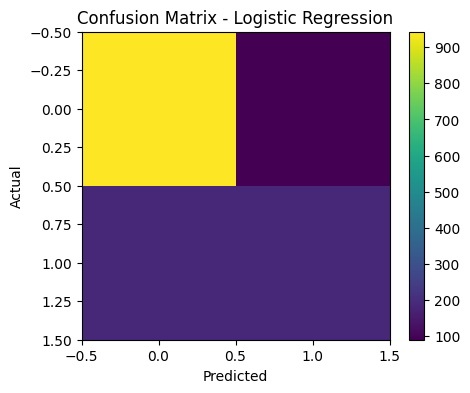

In [30]:
plt.figure(figsize=(5,4))
plt.imshow(cm)
plt.title("Confusion Matrix - Logistic Regression")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

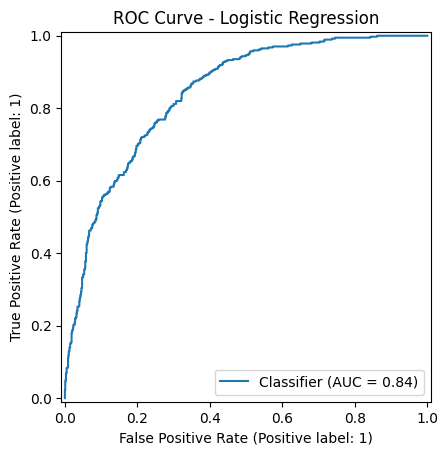

In [31]:
RocCurveDisplay.from_predictions(y_test, y_prob_log)
plt.title("ROC Curve - Logistic Regression")
plt.show()

In [32]:
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced"
    ))
])

rf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges',
                                                   'NumServices']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown=...ore'))]),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod',
                                                   'TenureGroup'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=200, random_state=42))])

In [33]:
y_pred_rf = rf_pipeline.predict(X_test)
y_prob_rf = rf_pipeline.predict_proba(X_test)[:, 1]

print("Random Forest Performance")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

Random Forest Performance
Accuracy: 0.7701067615658364
Precision: 0.5938697318007663
Recall: 0.4166666666666667
F1 Score: 0.48973143759873616
ROC-AUC: 0.814758142585017

Classification Report:

              precision    recall  f1-score   support

           0       0.81      0.90      0.85      1033
           1       0.59      0.42      0.49       372

    accuracy                           0.77      1405
   macro avg       0.70      0.66      0.67      1405
weighted avg       0.75      0.77      0.76      1405



In [34]:
model_comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_rf)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_rf)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_log),
        roc_auc_score(y_test, y_prob_rf)
    ]
})

print(model_comparison)

                 Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
0  Logistic Regression  0.802847   0.672727  0.497312  0.571870  0.840631
1        Random Forest  0.770107   0.593870  0.416667  0.489731  0.814758


In [35]:
# Get one-hot encoded feature names
ohe = rf_pipeline.named_steps["preprocessor"].named_transformers_["cat"].named_steps["onehot"]
encoded_cat_features = ohe.get_feature_names_out(categorical_features)

all_feature_names = numeric_features + list(encoded_cat_features)

# Get feature importances
importances = rf_pipeline.named_steps["classifier"].feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": all_feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print(feature_importance_df.head(15))

                           Feature  Importance
3                     TotalCharges    0.126525
2                   MonthlyCharges    0.115905
1                           tenure    0.114157
37         Contract_Month-to-month    0.062450
39               Contract_Two year    0.033119
19               OnlineSecurity_No    0.032031
28                  TechSupport_No    0.030597
17     InternetService_Fiber optic    0.030263
4                      NumServices    0.029433
44  PaymentMethod_Electronic check    0.028862
46         TenureGroup_0-12 Months    0.020563
6                      gender_Male    0.015308
5                    gender_Female    0.015255
0                    SeniorCitizen    0.015219
49          TenureGroup_49+ Months    0.015081


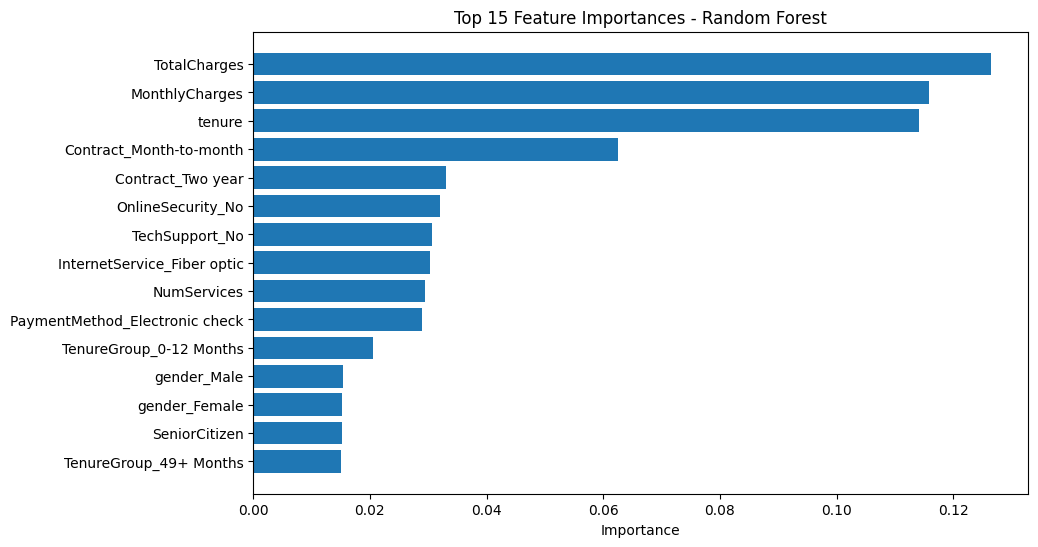

In [36]:
top_features = feature_importance_df.head(15)

plt.figure(figsize=(10,6))
plt.barh(top_features["Feature"][::-1], top_features["Importance"][::-1])
plt.xlabel("Importance")
plt.title("Top 15 Feature Importances - Random Forest")
plt.show()

In [37]:
# Extract trained logistic regression model
log_model = log_reg_pipeline.named_steps["classifier"]

# Get encoded feature names
ohe_log = log_reg_pipeline.named_steps["preprocessor"].named_transformers_["cat"].named_steps["onehot"]
encoded_cat_features_log = ohe_log.get_feature_names_out(categorical_features)
all_feature_names_log = numeric_features + list(encoded_cat_features_log)

coef_df = pd.DataFrame({
    "Feature": all_feature_names_log,
    "Coefficient": log_model.coef_[0]
}).sort_values(by="Coefficient", ascending=False)

print("Top features increasing churn probability:")
print(coef_df.head(10))

print("\nTop features decreasing churn probability:")
print(coef_df.tail(10))

Top features increasing churn probability:
                           Feature  Coefficient
37         Contract_Month-to-month     0.621788
49          TenureGroup_49+ Months     0.442332
17     InternetService_Fiber optic     0.332125
3                     TotalCharges     0.311728
44  PaymentMethod_Electronic check     0.188388
2                   MonthlyCharges     0.134932
19               OnlineSecurity_No     0.125620
28                  TechSupport_No     0.104056
0                    SeniorCitizen     0.094410
14  MultipleLines_No phone service     0.050608

Top features decreasing churn probability:
                     Feature  Coefficient
30           TechSupport_Yes    -0.221522
10            Dependents_Yes    -0.232492
21        OnlineSecurity_Yes    -0.243087
40       PaperlessBilling_No    -0.314241
13          MultipleLines_No    -0.319798
12          PhoneService_Yes    -0.335848
16       InternetService_DSL    -0.449592
47  TenureGroup_13-24 Months    -0.473006
39     

In [38]:
#EXAMPLE 1
sample_customer = pd.DataFrame([{
    "gender": "Female",
    "SeniorCitizen": 0,
    "Partner": "Yes",
    "Dependents": "No",
    "tenure": 5,
    "PhoneService": "Yes",
    "MultipleLines": "No",
    "InternetService": "Fiber optic",
    "OnlineSecurity": "No",
    "OnlineBackup": "No",
    "DeviceProtection": "No",
    "TechSupport": "No",
    "StreamingTV": "Yes",
    "StreamingMovies": "Yes",
    "Contract": "Month-to-month",
    "PaperlessBilling": "Yes",
    "PaymentMethod": "Electronic check",
    "MonthlyCharges": 85.5,
    "TotalCharges": 427.5,
    "TenureGroup": "0-12 Months",
    "NumServices": 4
}])

prediction = rf_pipeline.predict(sample_customer)[0]
probability = rf_pipeline.predict_proba(sample_customer)[0][1]

print("Predicted Churn:", prediction)
print("Churn Probability:", probability)

Predicted Churn: 1
Churn Probability: 0.72


In [39]:
#EXAMPLE 2
sample_customer = pd.DataFrame([{
    "gender": "Female",
    "SeniorCitizen": 0,
    "Partner": "Yes",
    "Dependents": "Yes",
    "tenure": 50,
    "PhoneService": "Yes",
    "MultipleLines": "No",
    "InternetService": "Fiber optic",
    "OnlineSecurity": "Yes",
    "OnlineBackup": "Yes",
    "DeviceProtection": "Yes",
    "TechSupport": "No",
    "StreamingTV": "Yes",
    "StreamingMovies": "Yes",
    "Contract": "Two year",
    "PaperlessBilling": "Yes",
    "PaymentMethod": "Credit card (automatic)",
    "MonthlyCharges": 55.0,
    "TotalCharges": 3300,
    "TenureGroup": "49+ Months",
    "NumServices": 6
}])

prediction = rf_pipeline.predict(sample_customer)[0]
probability = rf_pipeline.predict_proba(sample_customer)[0][1]

print("Predicted Churn:", prediction)
print("Churn Probability:", probability)

Predicted Churn: 0
Churn Probability: 0.135
